In [312]:
# Import relevant packages 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


from sklearn.impute import SimpleImputer  ## To impute missing values
plt.style.use("fivethirtyeight")


import warnings
warnings.filterwarnings("ignore")

### Load the Dataset

In [313]:
df = pd.read_csv("bitcoin_data/raw/btc_3h.csv")

In [314]:
df = df.sort_values('datetime')
df = df.set_index('datetime')

df['future_log_return'] = np.log(df['close'].shift(-1) / df['close'])

df['log_return'] = np.log(df['close'] / df['close'].shift(1))

df = df.dropna()

In [315]:
df.info()

<class 'pandas.DataFrame'>
Index: 18659 entries, 2020-01-01 03:00:00 to 2026-05-21 18:00:00
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   open               18659 non-null  float64
 1   high               18659 non-null  float64
 2   low                18659 non-null  float64
 3   close              18659 non-null  float64
 4   volume             18659 non-null  float64
 5   future_log_return  18659 non-null  float64
 6   log_return         18659 non-null  float64
dtypes: float64(7)
memory usage: 1.1+ MB


##### Time Features

In [316]:
df.index = pd.to_datetime(df.index)

In [317]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

df['is_weekend'] = (
    df.index.dayofweek >= 5
).astype(int)

df['is_month_end'] = (
    df.index.is_month_end
).astype(int)

### Feature Engeneering

##### Log features

In [318]:
cols = ['open', 'high', 'low', 'close', 'volume']

# ------------------------------------
# Create log returns first
# ------------------------------------
for col in cols:
    df[f'{col}_log_return'] = np.log(
        df[col] / df[col].shift(1)
    )

# ------------------------------------
# Create lagged log returns
# ------------------------------------
lags = [1, 2, 3, 5, 7, 14]

for col in cols:
    for lag in lags:
        df[f'{col}_log_return_lag_{lag}'] = (
            df[f'{col}_log_return'].shift(lag)
        )

##### Volatility Features

In [319]:

df['rolling_volatility_20'] = (
    df['log_return']
    .rolling(20)
    .std()
)

df['rolling_mean_20'] = (
    df['log_return']
    .rolling(20)
    .mean()
)

##### Lag Features

In [320]:
lags = [1, 2, 3, 5, 7, 14]

for col in cols:
    for lag in lags:
        df[f'{col}_log_return_lag_{lag}'] = df[f'{col}_log_return'].shift(lag)

In [321]:
cols = ['open', 'high', 'low', 'close', 'volume']
lags = [1, 2, 3, 5, 7, 14]

for col in cols:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

### Correlation

In [322]:
corr_matrix = df.select_dtypes(include=['number']).corr()

print(corr_matrix)

                   open      high       low     close    volume  \
open           1.000000  0.999915  0.999879  0.999848 -0.374647   
high           0.999915  1.000000  0.999821  0.999919 -0.372610   
low            0.999879  0.999821  1.000000  0.999907 -0.377629   
close          0.999848  0.999919  0.999907  1.000000 -0.374947   
volume        -0.374647 -0.372610 -0.377629 -0.374947  1.000000   
...                 ...       ...       ...       ...       ...   
volume_lag_2  -0.374831 -0.373964 -0.375908 -0.374851  0.733462   
volume_lag_3  -0.374835 -0.374129 -0.375636 -0.374757  0.679335   
volume_lag_5  -0.374618 -0.374085 -0.375158 -0.374495  0.677943   
volume_lag_7  -0.374335 -0.373656 -0.375005 -0.374267  0.718644   
volume_lag_14 -0.374130 -0.373867 -0.374415 -0.374110  0.636621   

               future_log_return  log_return      year     month       day  \
open                   -0.014160   -0.014386  0.786859  0.019876  0.002636   
high                   -0.014223   -0.0

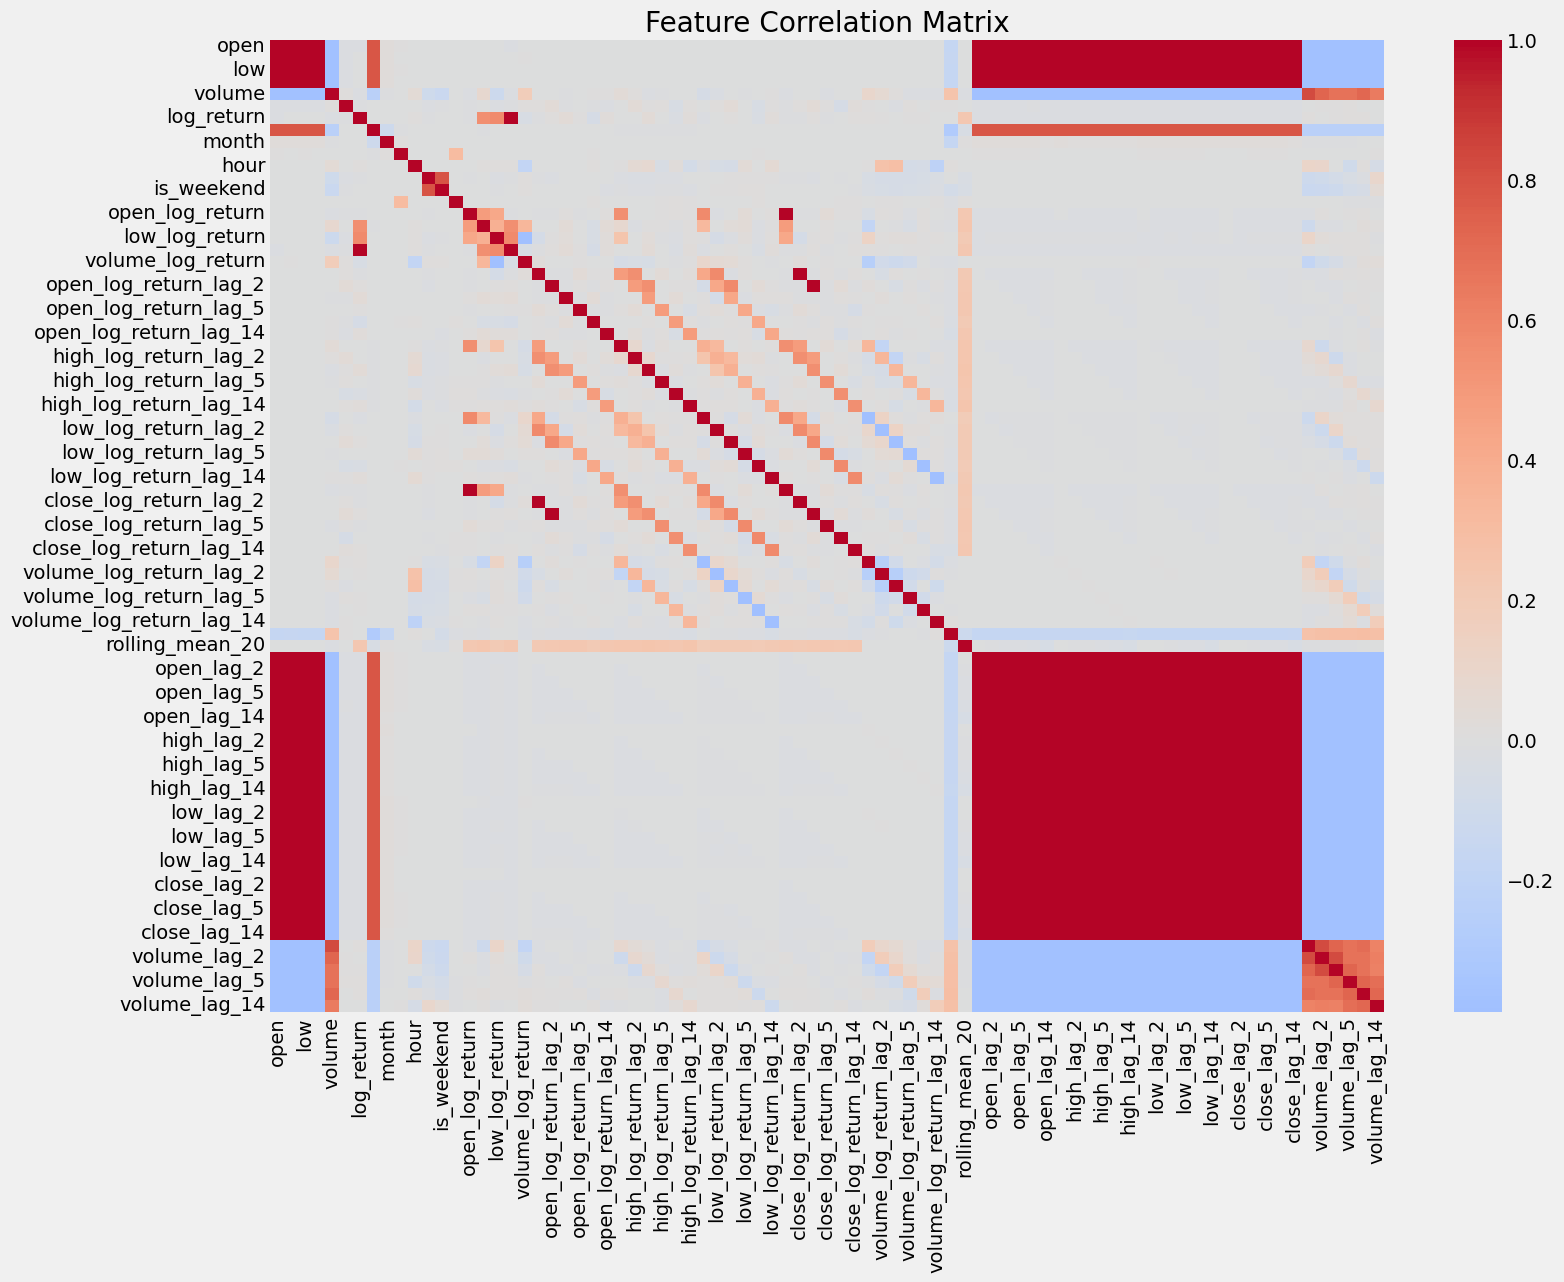

In [323]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')
plt.show()

### VIF

In [324]:
df.columns


Index(['open', 'high', 'low', 'close', 'volume', 'future_log_return',
       'log_return', 'year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend',
       'is_month_end', 'open_log_return', 'high_log_return', 'low_log_return',
       'close_log_return', 'volume_log_return', 'open_log_return_lag_1',
       'open_log_return_lag_2', 'open_log_return_lag_3',
       'open_log_return_lag_5', 'open_log_return_lag_7',
       'open_log_return_lag_14', 'high_log_return_lag_1',
       'high_log_return_lag_2', 'high_log_return_lag_3',
       'high_log_return_lag_5', 'high_log_return_lag_7',
       'high_log_return_lag_14', 'low_log_return_lag_1',
       'low_log_return_lag_2', 'low_log_return_lag_3', 'low_log_return_lag_5',
       'low_log_return_lag_7', 'low_log_return_lag_14',
       'close_log_return_lag_1', 'close_log_return_lag_2',
       'close_log_return_lag_3', 'close_log_return_lag_5',
       'close_log_return_lag_7', 'close_log_return_lag_14',
       'volume_log_return_lag_1', 'volume_

### Split the dataset

In [325]:

# Define the split date as a Timestamp object
split_date = "2026-04-21 00:00:00"

# Split the data set
data_train = df.loc[df.index <= split_date].copy()
data_test = df.loc[df.index > split_date].copy()

In [326]:
data_test.shape, data_train.shape

((246, 81), (18413, 81))

In [327]:
## Create dependent and independent variables

# Independent variables (features)
X_train = data_train.drop(['future_log_return'], axis=1)  

X_test = data_test.drop(['future_log_return'], axis=1)

# Dependent variable (target)
y_train = data_train['future_log_return']
y_test = data_test['future_log_return']

In [328]:
X_train.shape, X_test.shape

((18413, 80), (246, 80))

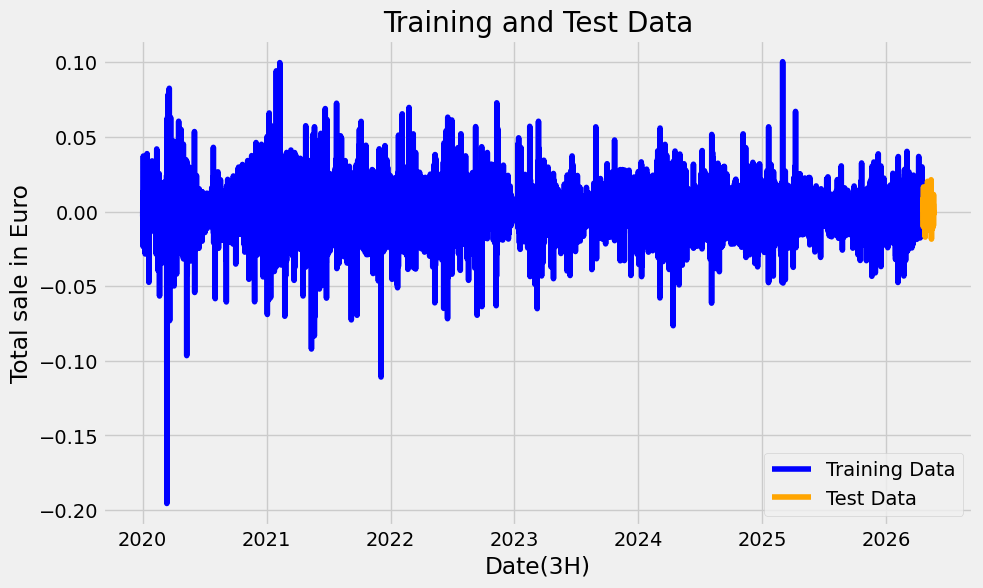

In [329]:
# Plotting
plt.figure(figsize=(10, 6))

# Plot training data
plt.plot(data_train.index, data_train['future_log_return'], label='Training Data', color='blue')

# Plot test data
plt.plot(data_test.index, data_test['future_log_return'], label='Test Data', color='orange')

plt.title('Training and Test Data')
plt.xlabel('Date(3H)')
plt.ylabel('Total sale in Euro')
plt.legend()

plt.show()

### XGBoost

In [330]:
# Now, create the DMatrix with enable_categorical=True
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical= True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical= True)

In [331]:
import skopt
from skopt import BayesSearchCV

from skopt.space import Real, Integer
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit


# Define the search space
param_space = {
    'learning_rate': Real(0.001, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 7),
    'n_estimators': Integer(100, 300),
    'reg_lambda': Real(0.1, 10, prior='log-uniform'),
    #'early_stopping_rounds': Integer(5, 20)  # Include early stopping rounds in the search space
    }


# Initialize XGBoost regressor
xgb_model = XGBRegressor()

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_iter=50,  # number of iterations
    verbose=1,
    n_jobs=-1  # parallel processing
    )

# Perform Bayesian optimization
bayes_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = bayes_search.best_params_
best_score = bayes_search.best_score_

print("Best parameters:", best_params)
print("Best score (negative MSE):", best_score)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [341]:
# Initialize the XGBoost regressor with the chosen hyperparameters
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=116,
    learning_rate=0.0013000196978705406,
    max_depth=3,
    reg_lambda=1.8512680539027102
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)


[0]	validation_0-rmse:0.00556
[100]	validation_0-rmse:0.00556
[115]	validation_0-rmse:0.00556


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [333]:
# Make predictions on the test data
xgb_predictions = model.predict(X_test)
#predictions = np.exp(xgb_predictions)

data_test['future_log_return_predictions'] = xgb_predictions

In [334]:
xgb_predictions

array([0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00025099, 0.00011677, 0.00011677, 0.00011677, 0.00025099,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00011677,
       0.00011677, 0.00011677, 0.00011677, 0.00011677, 0.00025

In [335]:
data_all = pd.concat([data_test, data_train], sort=False)

In [336]:
data_all.tail(10)

,open,high,low,close,volume,future_log_return,log_return,year,month,day,...,close_lag_5,close_lag_7,close_lag_14,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_5,volume_lag_7,volume_lag_14,future_log_return_predictions
datetime,,,,,,,,,,,,,,,,,,,,,
2026-04-19 21:00:00,74630.01,74810.00,73762.90,73801.79,1939.57994,0.008207,-0.011160,2026,4,19,...,75257.60,75496.00,77134.66,1290.70678,2297.16696,1821.11854,1490.51350,831.08883,951.05083,NaN
2026-04-20 00:00:00,73801.80,74746.93,73724.31,74410.01,2217.23360,-0.001962,0.008207,2026,4,20,...,75604.11,75545.60,76738.63,1939.57994,1290.70678,2297.16696,1055.11762,644.53015,1218.01906,NaN
2026-04-20 03:00:00,74410.01,74640.65,74095.18,74264.15,1144.71061,0.006239,-0.001962,2026,4,20,...,76024.01,75257.60,76039.05,2217.23360,1939.57994,1290.70678,1821.11854,1490.51350,1896.93702,NaN
2026-04-20 06:00:00,74264.16,75572.00,74250.00,74728.91,2155.57404,0.006187,0.006239,2026,4,20,...,74791.26,75604.11,76249.99,1144.71061,2217.23360,1939.57994,2297.16696,1055.11762,1411.42568,NaN
2026-04-20 09:00:00,74728.92,75404.63,74706.87,75192.71,1108.00520,-0.002102,0.006187,2026,4,20,...,74630.00,76024.01,75828.51,2155.57404,1144.71061,2217.23360,1290.70678,1821.11854,1039.54151,NaN
2026-04-20 12:00:00,75192.72,75766.74,74859.11,75034.79,2520.15505,0.011440,-0.002102,2026,4,20,...,73801.79,74791.26,75754.78,1108.00520,2155.57404,1144.71061,1939.57994,2297.16696,1270.76159,NaN
2026-04-20 15:00:00,75034.79,75991.47,74702.00,75898.14,2470.28010,0.004968,0.011440,2026,4,20,...,74410.01,74630.00,75691.76,2520.15505,1108.00520,2155.57404,2217.23360,1290.70678,495.59905,NaN
2026-04-20 18:00:00,75898.14,76558.62,75898.14,76276.17,4331.74296,-0.005722,0.004968,2026,4,20,...,74264.15,73801.79,75496.00,2470.28010,2520.15505,1108.00520,1144.71061,1939.57994,831.08883,NaN
2026-04-20 21:00:00,76276.18,76357.20,75617.60,75840.97,1045.70878,-0.003429,-0.005722,2026,4,20,...,74728.91,74410.01,75545.60,4331.74296,2470.28010,2520.15505,2155.57404,2217.23360,644.53015,NaN


In [337]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Calculate mean squared error
mRMSE = mean_squared_error(y_test, xgb_predictions)
print(f"Root Mean Squared Error: ", mRMSE)

# Calculate R-squared
mR2 = r2_score(y_test, xgb_predictions)
print(f"Mean Squared Error: ", mR2)

# Calculate mean absolute error
mMAE = mean_absolute_error(y_test, xgb_predictions)
print(f"Mean Absolute Error: ", mMAE)

Root Mean Squared Error:  3.095305928687354e-05
Mean Squared Error:  0.0002109895038354681
Mean Absolute Error:  0.0039265601480366055


### Plot Importance

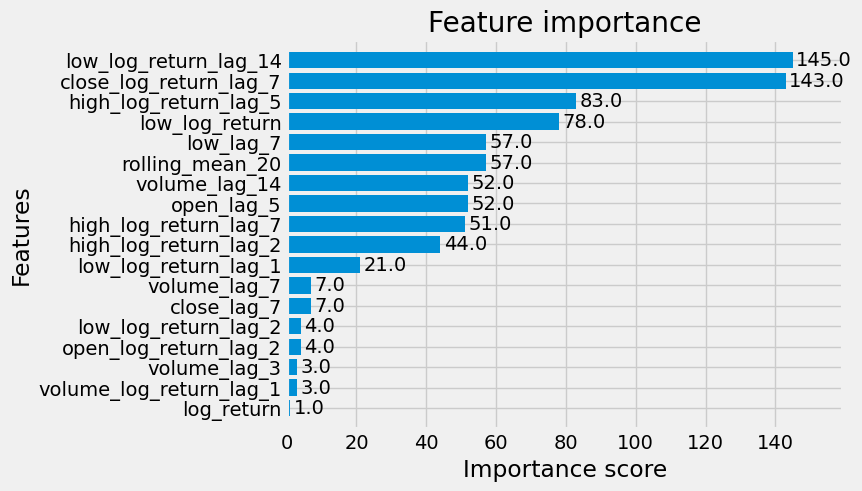

In [338]:
from xgboost import plot_importance

# Plot feature importances
plot_importance(model, max_num_features=25, height=0.8)  # Max 30 features
plt.show()

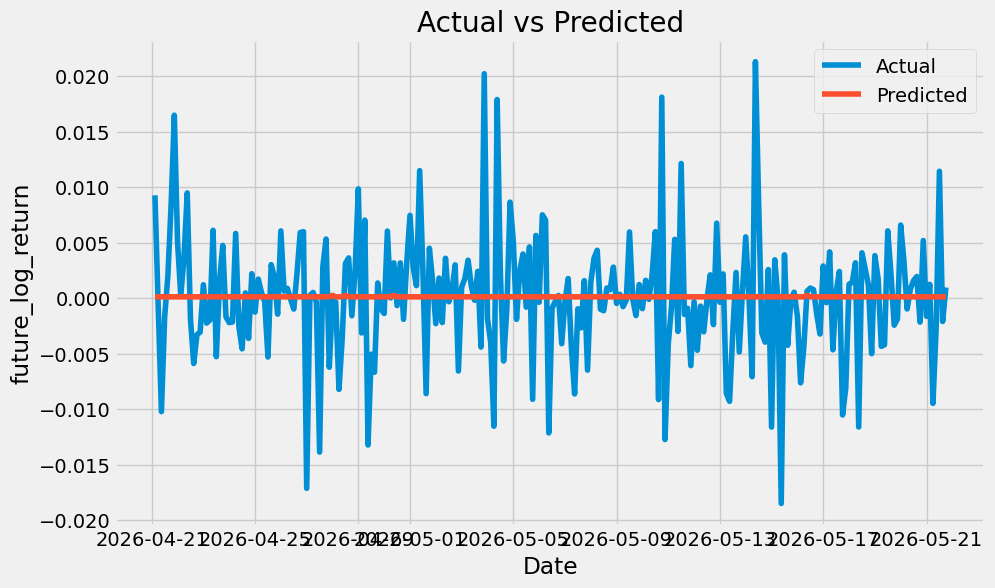

In [339]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, xgb_predictions, label='Predicted')
plt.xlabel('Date')
plt.ylabel('future_log_return')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

In [340]:
#data_test['error'] = data_test['future_log_return_predictions'] - data_test["future_log_return"]
#data_test['abs_error'] = data_test['error'].apply(np.abs)
#data_test['relative_deviation'] = (data_test['error']/ data_test['future_pct_move'])*100
#error_by_month = data_test.groupby(['year','month', "day", "hour"]).mean()[['future_log_return','future_log_return_predictions','error',]]
#error_by_month